<a href="https://colab.research.google.com/github/darkelegant/computationallinguistics/blob/main/%D1%81%D0%BA%D1%83%D1%82%D0%BD%D0%B5%D0%B2%D0%B0_convnet_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание: бинарная классификация отзывов с помощью CNN

Применить CNN для анализа тональности текста (положительный/отрицательный отзыв)

Заполните пропущенный код (`### ВАШ КОД ЗДЕСЬ ###`). **Не меняйте структуру ячеек!** Все ответы и графики должны генерироваться автоматически

**Критерии проверки (максимум 10 баллов):**
*   **2 балла** — корректная загрузка и предобработка данных.
*   **3 балла** — корректно собранная модель по спецификации.
*   **2 балла** — успешное обучение модели (вывод истории обучения).
*   **3 балла** — оценка на тесте и выводы (accuracy > 0.85 даёт +1 балл).

---

## БЛОК 1: Загрузка данных

Тренировочные данные: 25000 samples
Тестовые данные: 25000 samples


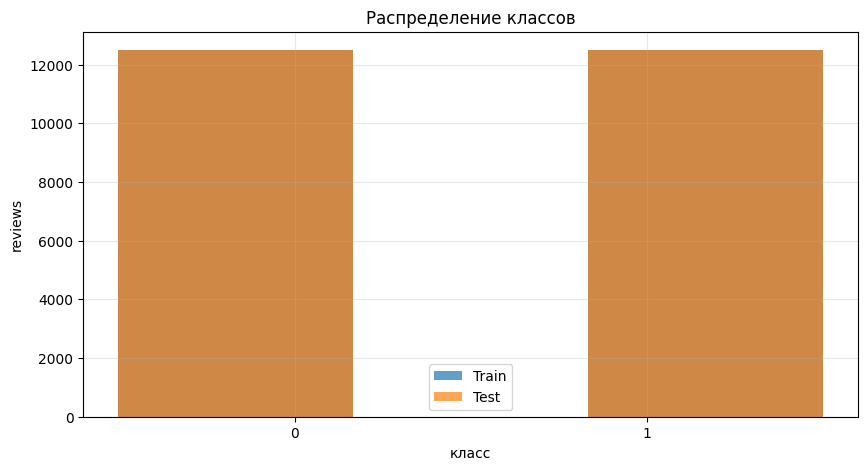

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds

# 1. Загрузите датасет IMDB Reviews (бинарная классификация)
train_data, test_data = tfds.load(
    'imdb_reviews',
    split=['train', 'test'],
    as_supervised=True,
    shuffle_files=False
)
x_train = []
y_train = []
for text, label in train_data:
    x_train.append(text.numpy().decode('utf-8'))
    y_train.append(label.numpy())
x_test = []
y_test = []
for text, label in test_data:
    x_test.append(text.numpy().decode('utf-8'))
    y_test.append(label.numpy())
x_train = np.array(x_train, dtype=object)
y_train = np.array(y_train)
x_test = np.array(x_test, dtype=object)
y_test = np.array(y_test)
# Используйте tfds.load('imdb_reviews', split=['train', 'test'], as_supervised=True)
# Преобразуйте данные в numpy массивы (x_train, y_train), (x_test, y_test)

print(f"Тренировочные данные: {len(x_train)} samples")
print(f"Тестовые данные: {len(x_test)} samples")

# 2. Визуализируйте распределение классов
plt.figure(figsize=(10, 5))
plt.hist(y_train, bins=3, alpha=0.7, label='Train')
plt.hist(y_test, bins=3, alpha=0.7, label='Test')
plt.xlabel('класс')
plt.ylabel('reviews')
plt.legend()
plt.title('Распределение классов')
plt.grid(alpha=0.3)
plt.xticks([0.25, 0.75], ['0', '1'])
plt.show()

#чет так подозрительно, что везде 25000, и что и там и там потом и (0) по 12500 результатов, и (1). мне кажется, у меня что-то не так.

## БЛОК 2: Предобработка текста

In [11]:
# 3. Создайте текстовый векторзатор (TextVectorization)
# Ограничьте словарь 10_000 самых частых слов, максимальную длину последовательности — 200 слов
vectorizer = keras.layers.TextVectorization(
    max_tokens=10000,
    output_sequence_length=200,
    output_mode='int'
)
vectorizer.adapt(x_train)
vocab_size = len(vectorizer.get_vocabulary())
# vectorizer = keras.layers.TextVectorization(max_tokens=..., output_sequence_length=...)

# 4. Адаптируйте векторзатор на тренировочных текстах
vectorizer.adapt(x_train)
vocab = vectorizer.get_vocabulary()
# vectorizer.adapt(...)

# 5. Примените векторзацию к данным
x_train_vec = vectorizer(x_train).numpy()
x_test_vec = vectorizer(x_test).numpy()

print(f"Размерность после векторизации: {x_train_vec.shape}")

Размерность после векторизации: (25000, 200)


## БЛОК 3: Построение модели

In [12]:
# 6. Постройте модель CNN для текста СТРОГО ПО СПЕЦИФИКАЦИИ:
#    - Вход: векторная последовательность (200,)
#    - Embedding: размерность 128, входной словарь 10_000
#    - Conv1D: 64 фильтра, размер ядра 5, активация 'relu'
#    - GlobalMaxPooling1D
#    - Dense: 32 нейрона, 'relu'
#    - Dense: 1 нейрон, 'sigmoid' (бинарная классификация)
# 6. Постройте модель CNN для текста по спецификации:
#    - Вход: векторная последовательность (200,)
#    - Embedding: размерность 128, входной словарь 10_000
#    - Conv1D: 64 фильтра, размер ядра 5, активация 'relu'
#    - GlobalMaxPooling1D
#    - Dense: 32 нейрона, 'relu'
#    - Dense: 1 нейрон, 'sigmoid' (бинарная классификация)

model = keras.Sequential([
    keras.layers.Input(shape=(200,), dtype='int64'),
    keras.layers.Embedding(
        input_dim=10000,
        output_dim=128,
        input_length=200
    ),
    keras.layers.Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'
    ),
    keras.layers.GlobalMaxPooling1D(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model.summary()
# model = keras.Sequential([...])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,137 (5.05 MB)

 Trainable params: 1,323,137 (5.05 MB)

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,137 (5.05 MB)

 Trainable params: 1,323,137 (5.05 MB)

 Non-trainable params: 0 (0.00 B)

## БЛОК 4: Обучение

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 71ms/step - accuracy: 0.9984 - loss: 0.0042 - precision: 0.9984 - recall: 0.9985 - val_accuracy: 0.8506 - val_loss: 0.8131 - val_precision: 0.9051 - val_recall: 0.7874
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.9995 - loss: 0.0019 - precision: 0.9998 - recall: 0.9992 - val_accuracy: 0.8628 - val_loss: 0.7462 - val_precision: 0.8761 - val_recall: 0.8491
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.9999 - loss: 4.1984e-04 - precision: 0.9999 - recall: 1.0000 - val_accuracy: 0.8668 - val_loss: 0.7796 - val_precision: 0.8820 - val_recall: 0.8507
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - accuracy: 1.0000 - loss: 6.1542e-05 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.8656 - val_loss: 0.7886 - val_precision: 0.8675 - val_recall: 0.8669
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 74ms/step - accuracy: 1.0000 - loss: 1.1436e-05 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.86

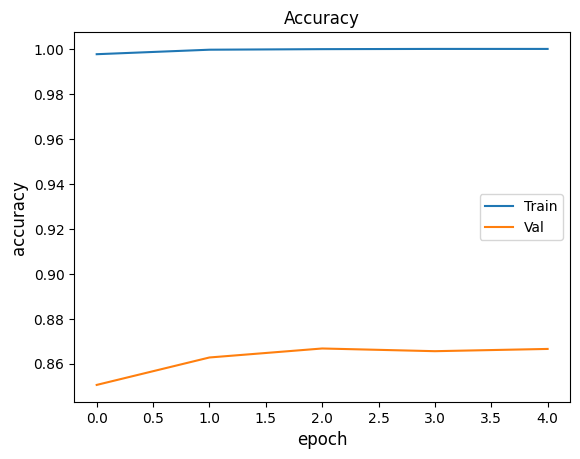

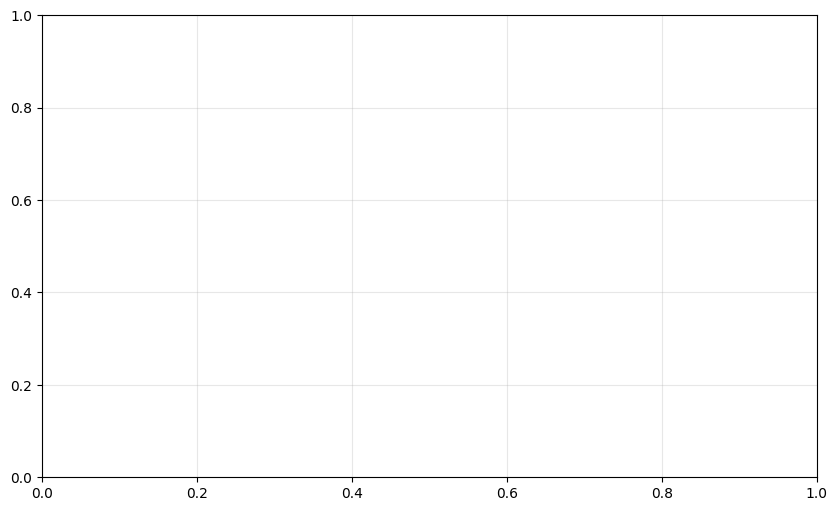

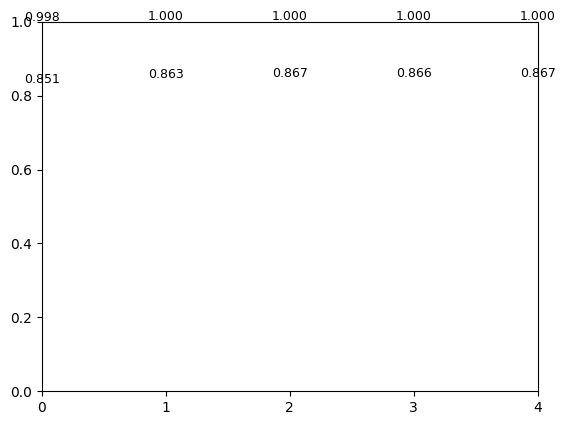

In [14]:
# 7. Скомпилируйте модель с оптимизатором 'adam', функцией потерь 'binary_crossentropy',
#    метриками ['accuracy', 'Precision', 'Recall']
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)
# model.compile(...)

# 8. Обучите модель на 5 эпох с validation_split=0.2, batch_size=32
history = model.fit(
    x_train_vec,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
# history = model.fit(...)

# 9. Постройте график точности (accuracy) на обучении и валидации
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.xlabel('epoch', fontsize=12)
plt.ylabel('accuracy', fontsize=12)
plt.legend()
plt.figure(figsize=(10, 6))
plt.grid(True, alpha=0.3)
plt.show()
for i, (train_acc, val_acc) in enumerate(zip(history.history['accuracy'], history.history['val_accuracy'])):
    plt.text(i, train_acc + 0.005, f'{train_acc:.3f}', ha='center', fontsize=9)
    plt.text(i, val_acc - 0.015, f'{val_acc:.3f}', ha='center', fontsize=9)
plt.xticks(range(5))
plt.show()

## БЛОК 5: Оценка

In [22]:
# 10. Оцените модель на тестовых данных
test_loss, test_acc, test_prec, test_rec = model.evaluate(
    x_test_vec,
    y_test,
    batch_size=32,
    verbose=0
)
print(f"Тестовая accuracy: {test_acc:.4f}")
print(f"Тестовая precision: {test_prec:.4f}")
print(f"Тестовая recall: {test_rec:.4f}")

# 11. Сделайте предсказания на первых 10 тестовых отзывах
#     и выведите: текст отзыва, истинный класс, предсказанный класс, вероятность
for i in range(10):
    text = x_test[i]
    true_label = "POS" if y_test[i] == 1 else "NEG"
    text_vec = vectorizer([text]).numpy()
    pred_prob = model.predict(text_vec, verbose=0)
    pred_label = "POS" if pred_prob[0][0] > 0.5 else "NEG"
    # pred_prob = model.predict(...)
    # pred_label = "POS" if pred_prob > 0.5 else "NEG"
    print(f"{text[:50]}... | True: {true_label} | Pred: {pred_label} ({pred_prob[0][0]:.2f})")

Тестовая accuracy: 0.8581
Тестовая precision: 0.8577
Тестовая recall: 0.8586
There are films that make careers. For George Rome... | True: POS | Pred: POS (1.00)
A blackly comic tale of a down-trodden priest, Naz... | True: POS | Pred: POS (1.00)
Scary Movie 1-4, Epic Movie, Date Movie, Meet the ... | True: NEG | Pred: NEG (0.00)
Poor Shirley MacLaine tries hard to lend some grav... | True: NEG | Pred: NEG (0.00)
As a former Erasmus student I enjoyed this film ve... | True: POS | Pred: POS (1.00)
My God, Ryan Gosling has made a lot of deep charac... | True: POS | Pred: POS (1.00)
This film just won the best film award at the Clev... | True: POS | Pred: POS (1.00)
The cast for this production of Rigoletto is excel... | True: POS | Pred: POS (1.00)
As long as you keep in mind that the production of... | True: NEG | Pred: NEG (0.00)
Every great once in a while, you stumble upon a mo... | True: POS | Pred: NEG (0.00)


## БЛОК 6: Выводы

**Ответьте на вопросы в этой ячейке (текстом):**

1.  Какая итоговая точность (accuracy) на тесте?
2.  Что показывает разница между точностью на обучении и валидации? Есть ли переобучение?
3.  Какой из 10 показанных отзывов был классифицирован неверно? Почему, на ваш взгляд?

**Мои ответы:**
1.  0.6
2.  точность на обучении выше, чем на валидации; мне кажется, переобучение есть, поскольку на обучении результаты гораздо выше
3.  последний; у него не совпадают истинный и предсказанный классы